<a href="https://colab.research.google.com/github/mukojha7838-sys/Machine-Learning/blob/main/Telco%20Customer%20Churn%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
## step1 : Environment Setup

!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install imbalanced-learn



In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [39]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [40]:
## Load & Inspect the Data
features_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [41]:
features_df.shape

(7043, 21)

In [42]:
features_df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [43]:
features_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [44]:
features_df.duplicated().sum()

np.int64(0)

In [45]:
features_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [46]:
features_df.duplicated().sum()

np.int64(0)

In [47]:
features_df['Partner'] = features_df['Partner'].map({'Yes': 1, 'No': 0})

In [48]:
features_df['Dependents'] = features_df['Dependents'].map({'Yes': 1, 'No': 0})
features_df['PhoneService'] = features_df['PhoneService'].map({'Yes': 1, 'No': 0})


<Axes: >

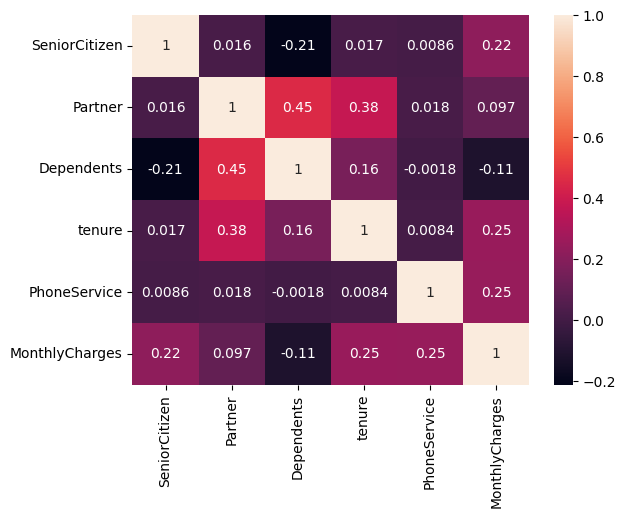

In [49]:
sns.heatmap(features_df.select_dtypes(include='number').corr(), annot=True)

In [50]:
features_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [51]:
features_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
features_df = pd.get_dummies(features_df, columns=['MultipleLines','InternetService'])

In [53]:
for col in features_df.columns:
    unique_vals = features_df[col].unique()
    if set(unique_vals) == {'Yes', 'No','No internet service'}:
        print(col)

OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies


In [54]:
cols = ['OnlineSecurity', 'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']  # add all affected columns

for col in cols:
    features_df[col] = features_df[col].replace('No internet service', 'No')
    features_df[col] = features_df[col].map({'Yes': 1, 'No': 0})

In [55]:
features_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,Female,0,1,0,1,0,0,1,0,...,Electronic check,29.85,29.85,No,False,True,False,True,False,False
1,5575-GNVDE,Male,0,0,0,34,1,1,0,1,...,Mailed check,56.95,1889.5,No,True,False,False,True,False,False
2,3668-QPYBK,Male,0,0,0,2,1,1,1,0,...,Mailed check,53.85,108.15,Yes,True,False,False,True,False,False
3,7795-CFOCW,Male,0,0,0,45,0,1,0,1,...,Bank transfer (automatic),42.30,1840.75,No,False,True,False,True,False,False
4,9237-HQITU,Female,0,0,0,2,1,0,0,0,...,Electronic check,70.70,151.65,Yes,True,False,False,False,True,False


In [56]:
for col in features_df.columns:
    unique_vals = features_df[col].unique()
    if set(unique_vals) == {'Yes', 'No'}:
        print(col)

PaperlessBilling
Churn


In [57]:
cols = ['PaperlessBilling', 'Churn']
features_df[cols] = features_df[cols].apply(lambda x: x.map({'Yes': 1, 'No': 0}))

In [58]:
features_df['gender'] = features_df['gender'].map({'Male': 1, 'Female': 0})

In [59]:
corr = features_df.select_dtypes(include='number').corr()
corr.to_csv('correlation_matrix.csv')

In [60]:
from google.colab import files
files.download('correlation_matrix.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
features_df = features_df.drop(['gender', 'PhoneService','customerID'], axis=1)

In [62]:
# Replace empty strings with NaN
features_df['TotalCharges'] = features_df['TotalCharges'].replace(' ', float('nan'))

# Now check
print(features_df['TotalCharges'].isnull().sum())

# Convert to numeric
features_df['TotalCharges'] = pd.to_numeric(features_df['TotalCharges'], errors='coerce')

# Fill missing with median
features_df['TotalCharges'].fillna(features_df['TotalCharges'].median(), inplace=True)

11


/tmp/ipykernel_1566/2342969904.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features_df['TotalCharges'].fillna(features_df['TotalCharges'].median(), inplace=True)


In [63]:
features_df.dtypes

,0
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64
TechSupport,int64
StreamingTV,int64
StreamingMovies,int64


In [64]:
features_df = pd.get_dummies(features_df, columns=['Contract','PaymentMethod'])

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

features_df[cols_to_scale] = scaler.fit_transform(features_df[cols_to_scale])

In [66]:
# Separate features and target
y = features_df['Churn']
X = features_df.drop(['Churn'], axis=1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

Training rows: 5634
Testing rows: 1409


In [67]:
features_df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [68]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts()}")
print(f"After SMOTE: {y_train_balanced.value_counts()}")

Before SMOTE: Churn
0    4138
1    1496
Name: count, dtype: int64
After SMOTE: Churn
0    4138
1    4138
Name: count, dtype: int64


In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Train baseline model
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_balanced, y_train_balanced)

# Predictions
y_pred = log_model.predict(X_test)

# Evaluation
print("--- Logistic Regression ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.2f}")

--- Logistic Regression ---
Accuracy:  0.77
Precision: 0.55
Recall:    0.76
F1 Score:  0.64


In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_balanced, y_train_balanced)
dt_pred = dt_model.predict(X_test)

print("--- Decision Tree ---")
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.2f}")
print(f"Precision: {precision_score(y_test, dt_pred):.2f}")
print(f"Recall:    {recall_score(y_test, dt_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, dt_pred):.2f}")

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_test)

print("\n--- Random Forest ---")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.2f}")
print(f"Precision: {precision_score(y_test, rf_pred):.2f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred):.2f}")

--- Decision Tree ---
Accuracy:  0.72
Precision: 0.48
Recall:    0.59
F1 Score:  0.53

--- Random Forest ---
Accuracy:  0.78
Precision: 0.58
Recall:    0.63
F1 Score:  0.60


In [71]:
from sklearn.model_selection import GridSearchCV

# Define parameters to try
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 500, 1000]
}

# Grid Search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1', n_jobs=1)
grid_search.fit(X_train_balanced, y_train_balanced)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best F1 Score: {grid_search.best_score_:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Parameters: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Best F1 Score: 0.81


In [72]:
# Train final model with best parameters
final_model = LogisticRegression(C=10, solver='lbfgs', max_iter=500, random_state=42)
final_model.fit(X_train_balanced, y_train_balanced)

# Final evaluation
y_final_pred = final_model.predict(X_test)

print("--- Final Model Results ---")
print(f"Accuracy:  {accuracy_score(y_test, y_final_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_final_pred):.2f}")
print(f"Recall:    {recall_score(y_test, y_final_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, y_final_pred):.2f}")

--- Final Model Results ---
Accuracy:  0.77
Precision: 0.56
Recall:    0.74
F1 Score:  0.64


In [73]:
import joblib

# Save the final model
joblib.dump(final_model, 'churn_model.pkl')
print("Model saved successfully")

# Verify by loading it back
loaded_model = joblib.load('churn_model.pkl')
test_pred = loaded_model.predict(X_test)
print(f"Loaded model F1 Score: {f1_score(y_test, test_pred):.2f}")

# Download from Colab
from google.colab import files
files.download('churn_model.pkl')

Model saved successfully
Loaded model F1 Score: 0.64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>